In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv(r"C:\Users\MY PC\Desktop\ML\projects\wine\wine_data.csv", header=0, usecols=[0,1,2])

In [35]:
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [36]:
df

,Class label,Alcohol,Malic acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

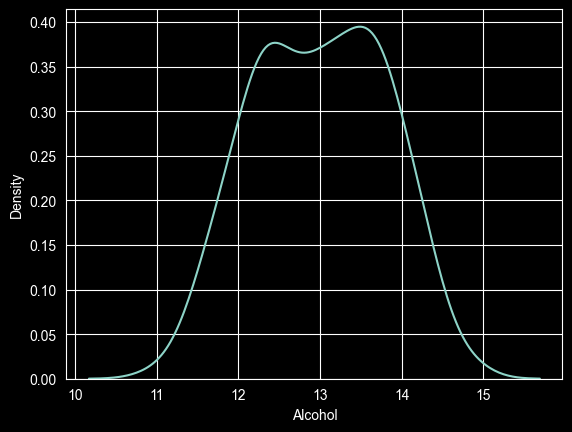

In [37]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

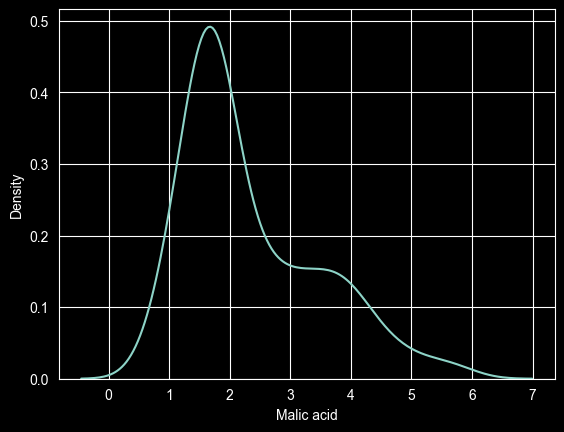

In [38]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

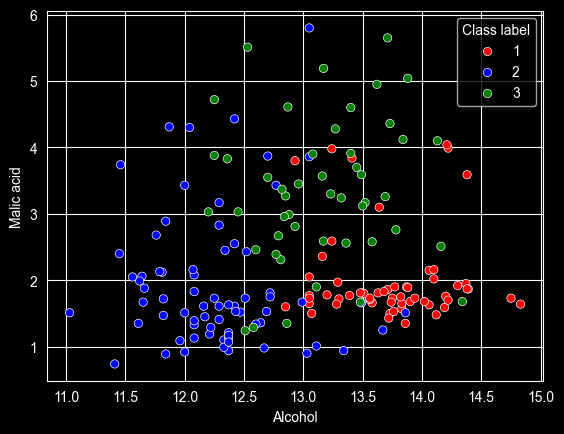

In [39]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(x=df['Alcohol'], y=df['Malic acid'], hue=df['Class label'], palette=color_dict)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((123, 2), (54, 2))

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [43]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,123.0,123.0
mean,13.0,2.3
std,0.8,1.2
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.1
max,14.8,5.8


In [44]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


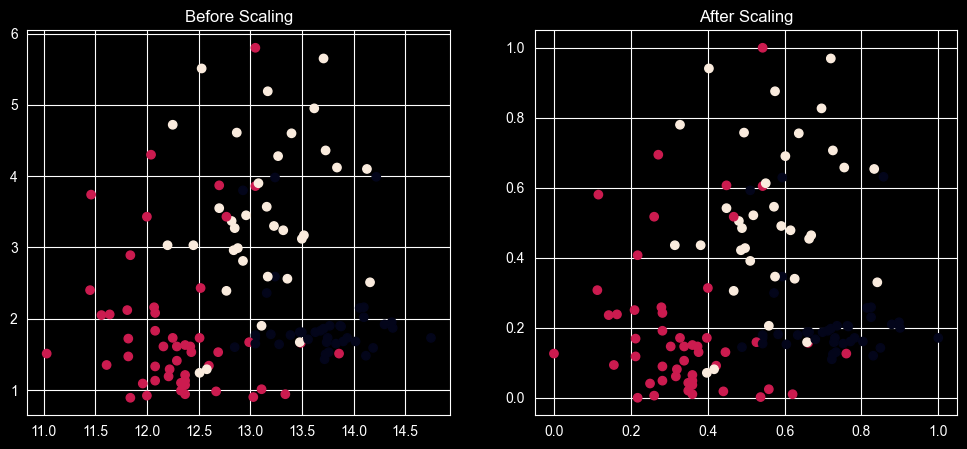

In [45]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax2.set_title("After Scaling")
plt.show()

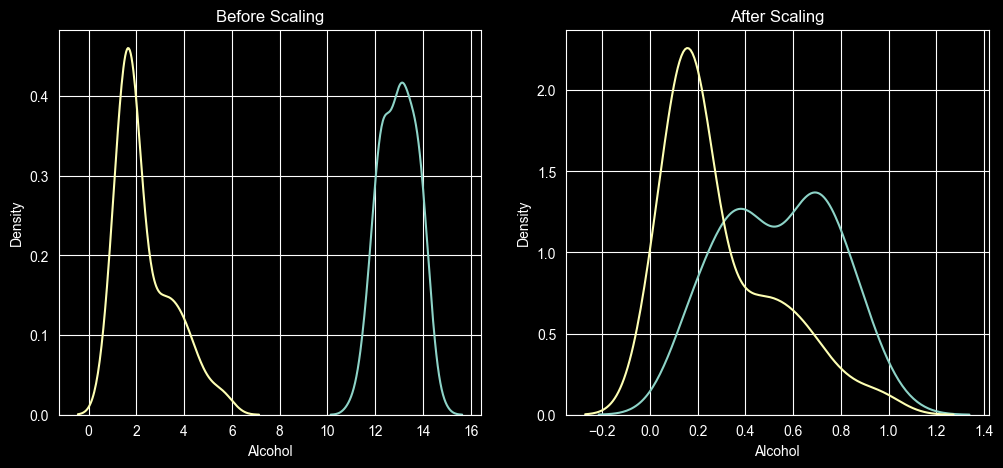

In [46]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_test_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)

plt.show()

# Column Transformer

In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [48]:
data = pd.read_csv('covid_toy.csv')

In [49]:
data.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [50]:
data.shape

(100, 6)

In [51]:
data['city'].value_counts()

city
Kolkata      32
Bangalore    30
Delhi        22
Mumbai       16
Name: count, dtype: int64

In [52]:
data.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['has_covid']),data['has_covid'], test_size=0.2)

In [54]:
X_train

,age,gender,fever,cough,city
10,75,Female,NaN,Mild,Delhi
21,73,Male,98.0,Mild,Bangalore
65,69,Female,102.0,Mild,Bangalore
88,5,Female,100.0,Mild,Kolkata
42,27,Male,100.0,Mild,Delhi
...,...,...,...,...,...
69,73,Female,103.0,Mild,Delhi
26,19,Female,100.0,Mild,Kolkata
98,5,Female,98.0,Strong,Mumbai
52,47,Female,100.0,Strong,Bangalore


# Aam Zindagi

In [55]:
# adding simple imputer to fever col
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['fever']])

#Also test data
X_test_fever = si.transform(X_test[['fever']])

X_train_fever.shape

(80, 1)

In [56]:
# Ordinal encoding -> cough

oe = OrdinalEncoder(categories=[['Mild', 'Strong']])
X_train_cough = oe.fit_transform(X_train[['cough']])
X_test_cough = oe.transform(X_test[['cough']])
X_train_cough.shape

(80, 1)

In [57]:
# One hot encoding -> Gender, city

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_gender_city = ohe.fit_transform(X_train[['gender', 'city']])

X_test_gender_city = ohe.fit_transform(X_test[['gender', 'city']])

X_train_gender_city.shape


(80, 4)

In [58]:
# Extracting age
X_train_age = X_train.drop(columns=['gender', 'fever', 'cough', 'city']).values

X_test_age = X_test.drop(columns=['gender', 'fever', 'cough', 'city']).values

X_train_age.shape

(80, 1)

In [60]:
X_train_transformed = np.concatenate((X_train_age, X_train_fever, X_train_gender_city, X_train_cough), axis=1)

X_test_transformed = np.concatenate((X_test_age, X_test_fever, X_test_gender_city, X_test_cough), axis=1)

X_train_transformed.shape

(80, 7)

# Mentos Zindagi
by a column transformer

In [61]:
from sklearn.compose import ColumnTransformer

In [65]:
transformer = ColumnTransformer(transformers=[
    ('tnf1', SimpleImputer(), ['fever']),
    ('tnf2', OrdinalEncoder(categories=[['Mild', 'Strong']]),['cough']),
    ('tnf3', OneHotEncoder(drop='first', sparse_output=False), ['gender', 'city']),
], remainder='passthrough')

In [68]:
transformer.fit_transform(X_train)

array([[100.84722222,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  75.        ],
       [ 98.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,  73.        ],
       [102.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  69.        ],
       [100.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ,   5.        ],
       [100.        ,   0.        ,   1.        ,   1.        ,
          0.        ,   0.        ,  27.        ],
       [101.        ,   1.        ,   0.        ,   1.        ,
          0.        ,   0.        ,  68.        ],
       [103.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  16.        ],
       [102.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   1.        ,  74.        ],
       [104.        ,   0.        ,   0.        ,   0.        ,
          0.    

In [70]:
transformer.fit_transform(X_test).shape

(20, 7)

# Pipelines